# Chest X-Ray Preprocessing Pipeline
**Assignment:** Pulmonary Imaging Lab — Pneumonia Detection

Operations covered:
1. Load & Display
2. Histogram Equalization
3. Color Mapping (COLORMAP_JET)
4. Color Balance
5. Color Filtering / Thresholding
6. Logarithmic Transformation
7. Power-Law (Gamma) Transformation

In [1]:
!pip install -q opencv-python-headless matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import files
import urllib.request, os

print('cv2:', cv2.__version__)
print('numpy:', np.__version__)

cv2: 5.0.0
numpy: 2.1.3


In [6]:
# uploaded = files.upload()
# IMAGE_PATH = list(uploaded.keys())[0]

IMAGE_PATH = '/content/PNEUMONIA_10.png'
print(f'Using existing file: {IMAGE_PATH}')

Using existing file: /content/PNEUMONIA_10.png


Image shape : (232, 232)  dtype: uint8
Raw   — min=  0  max=255  mean=98.6
Under — min=  0  max= 89  mean=34.0


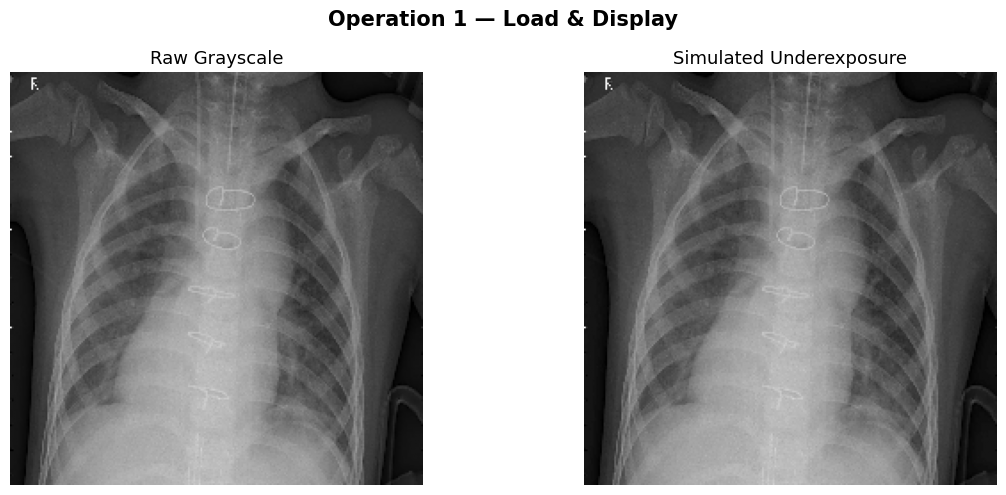

In [7]:
UNDEREXPOSE_FACTOR = 0.35

bgr      = cv2.imread(IMAGE_PATH)
raw_gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

# simulate underexposure
underexposed = np.clip(raw_gray.astype(np.float32) * UNDEREXPOSE_FACTOR,
                       0, 255).astype(np.uint8)

print(f'Image shape : {raw_gray.shape}  dtype: {raw_gray.dtype}')
print(f'Raw   — min={raw_gray.min():3d}  max={raw_gray.max():3d}  mean={raw_gray.mean():.1f}')
print(f'Under — min={underexposed.min():3d}  max={underexposed.max():3d}  mean={underexposed.mean():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raw_gray,    cmap='gray'); axes[0].set_title('Raw Grayscale',         fontsize=13); axes[0].axis('off')
axes[1].imshow(underexposed,cmap='gray'); axes[1].set_title('Simulated Underexposure',fontsize=13); axes[1].axis('off')
plt.suptitle('Operation 1 — Load & Display', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

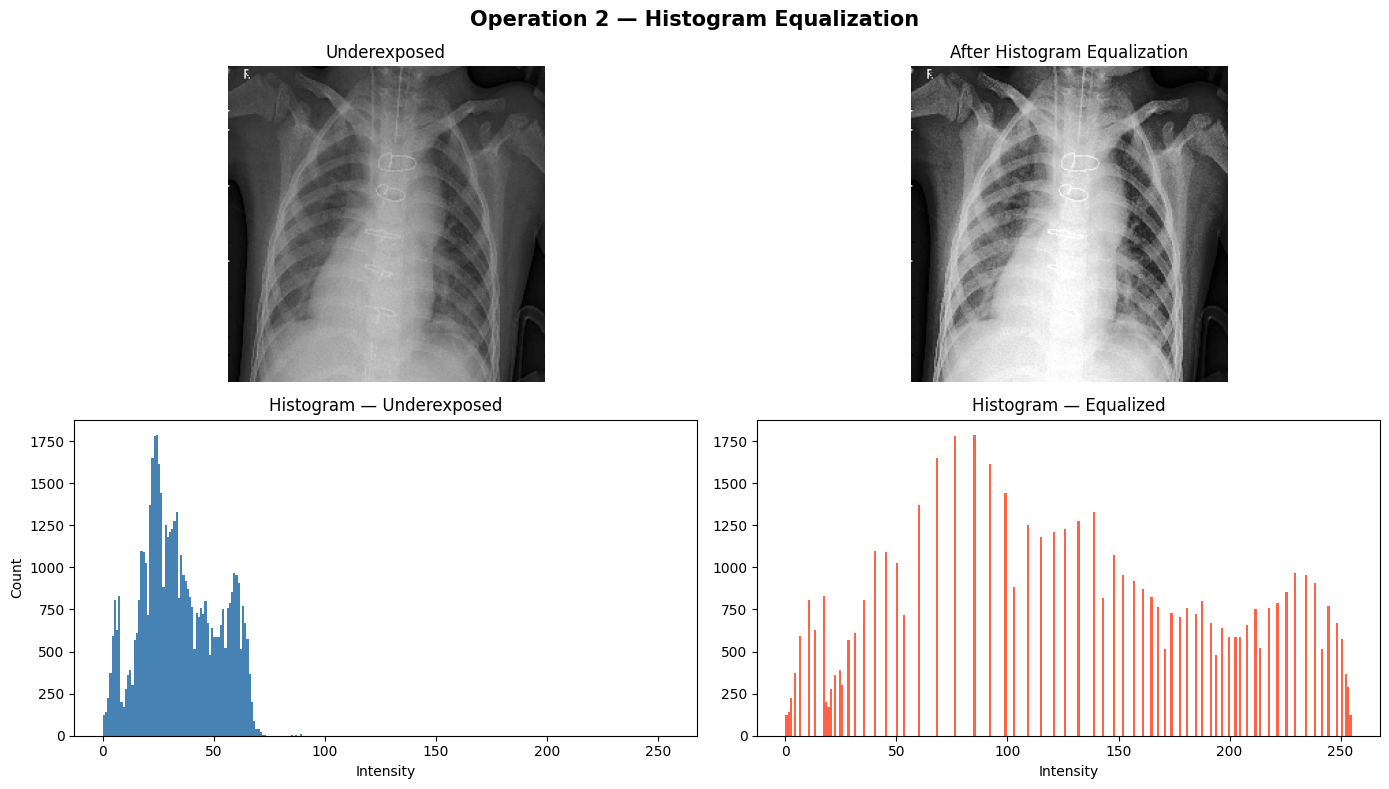

Mean before: 34.0  →  after: 129.5


In [8]:
equalized = cv2.equalizeHist(underexposed)

# side-by-side histogram
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0][0].imshow(underexposed, cmap='gray'); axes[0][0].set_title('Underexposed'); axes[0][0].axis('off')
axes[0][1].imshow(equalized,    cmap='gray'); axes[0][1].set_title('After Histogram Equalization'); axes[0][1].axis('off')

axes[1][0].hist(underexposed.ravel(), bins=256, range=(0,255), color='steelblue')
axes[1][0].set_title('Histogram — Underexposed'); axes[1][0].set_xlabel('Intensity'); axes[1][0].set_ylabel('Count')

axes[1][1].hist(equalized.ravel(), bins=256, range=(0,255), color='tomato')
axes[1][1].set_title('Histogram — Equalized'); axes[1][1].set_xlabel('Intensity')

plt.suptitle('Operation 2 — Histogram Equalization', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Mean before: {underexposed.mean():.1f}  →  after: {equalized.mean():.1f}')

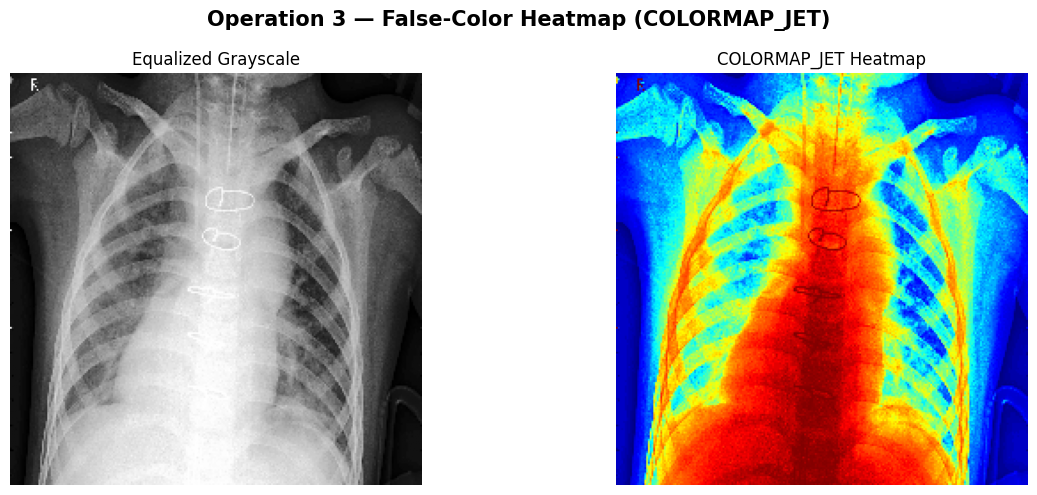

In [9]:
jet_bgr = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
jet_rgb = cv2.cvtColor(jet_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(equalized, cmap='gray'); axes[0].set_title('Equalized Grayscale'); axes[0].axis('off')
axes[1].imshow(jet_rgb);                axes[1].set_title('COLORMAP_JET Heatmap'); axes[1].axis('off')
plt.suptitle('Operation 3 — False-Color Heatmap (COLORMAP_JET)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

Channel means — B:117.6  G:128.7  R:121.3  global:122.6


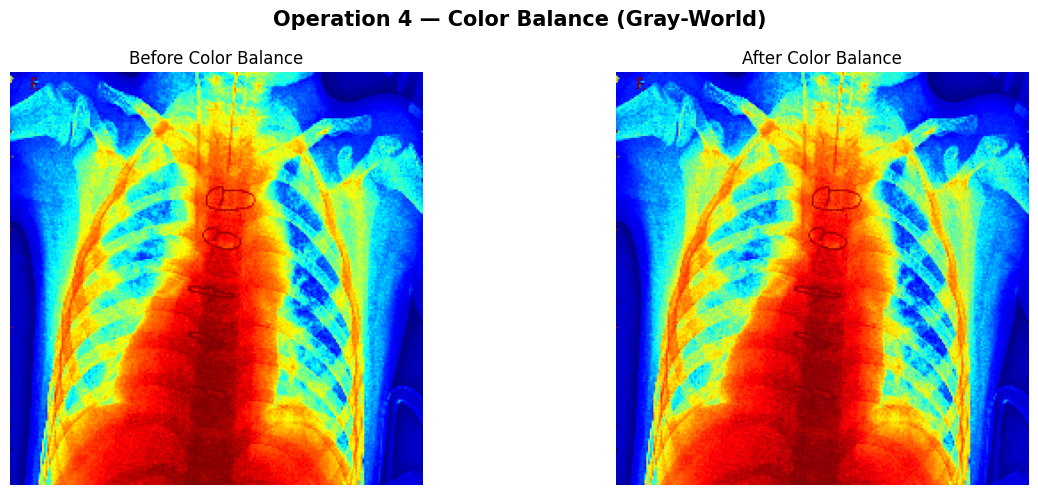

In [10]:
bgr_f   = jet_bgr.astype(np.float32)
means   = [bgr_f[:,:,c].mean() for c in range(3)]
gm      = np.mean(means)

balanced_bgr = bgr_f.copy()
for c in range(3):
    balanced_bgr[:,:,c] = np.clip(bgr_f[:,:,c] + (gm - means[c]), 0, 255)
balanced_bgr = balanced_bgr.astype(np.uint8)
balanced_rgb = cv2.cvtColor(balanced_bgr, cv2.COLOR_BGR2RGB)

print(f'Channel means — B:{means[0]:.1f}  G:{means[1]:.1f}  R:{means[2]:.1f}  global:{gm:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(jet_rgb);     axes[0].set_title('Before Color Balance'); axes[0].axis('off')
axes[1].imshow(balanced_rgb);axes[1].set_title('After Color Balance');  axes[1].axis('off')
plt.suptitle('Operation 4 — Color Balance (Gray-World)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

Threshold=200 → 21.6% of pixels retained (dense tissue)


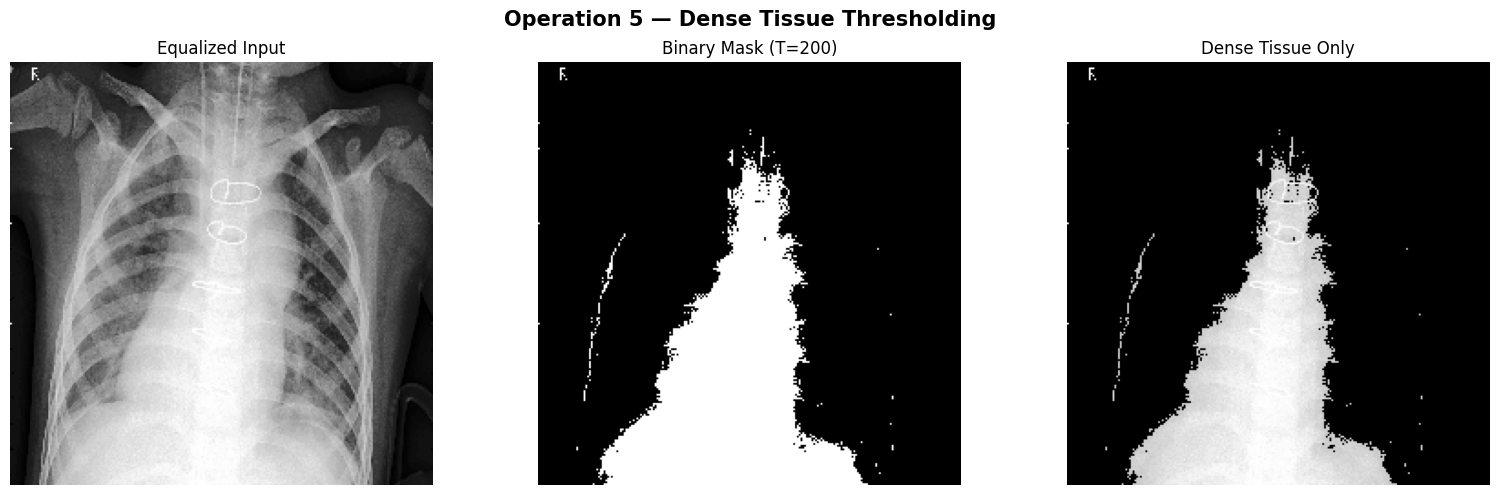

In [11]:
DENSE_THRESHOLD = 200

_, mask      = cv2.threshold(equalized, DENSE_THRESHOLD, 255, cv2.THRESH_BINARY)
dense_masked = cv2.bitwise_and(equalized, equalized, mask=mask)

pct = 100 * np.sum(mask == 255) / equalized.size
print(f'Threshold={DENSE_THRESHOLD} → {pct:.1f}% of pixels retained (dense tissue)')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(equalized,    cmap='gray'); axes[0].set_title('Equalized Input');      axes[0].axis('off')
axes[1].imshow(mask,         cmap='gray'); axes[1].set_title(f'Binary Mask (T={DENSE_THRESHOLD})'); axes[1].axis('off')
axes[2].imshow(dense_masked, cmap='gray'); axes[2].set_title('Dense Tissue Only');    axes[2].axis('off')
plt.suptitle('Operation 5 — Dense Tissue Thresholding', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

Log transform — input mean=34.0  output mean=191.9


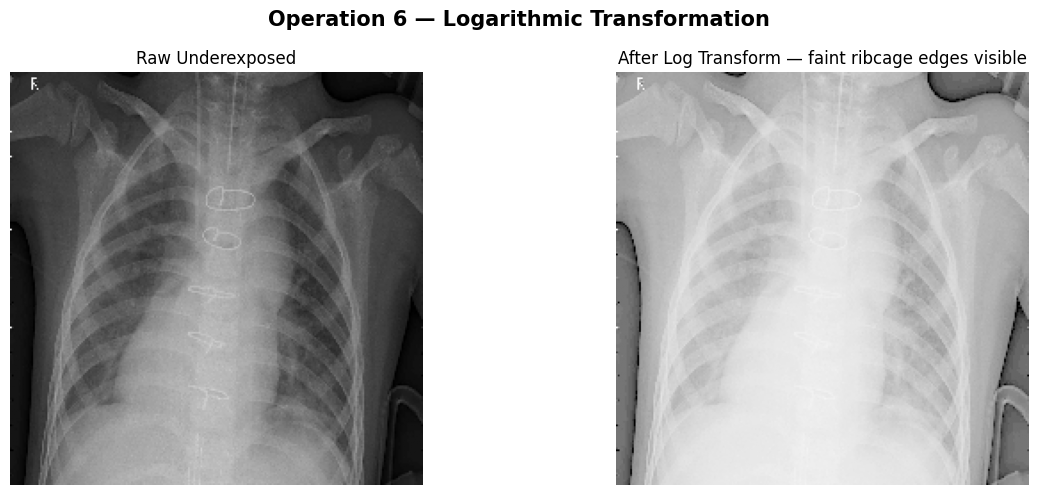

In [12]:
LOG_C = 1.0

log_img  = LOG_C * np.log1p(underexposed.astype(np.float32))  # log1p = log(1+x)
log_out  = (log_img / log_img.max() * 255).astype(np.uint8)

print(f'Log transform — input mean={underexposed.mean():.1f}  output mean={log_out.mean():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(underexposed, cmap='gray'); axes[0].set_title('Raw Underexposed'); axes[0].axis('off')
axes[1].imshow(log_out,      cmap='gray'); axes[1].set_title('After Log Transform — faint ribcage edges visible'); axes[1].axis('off')
plt.suptitle('Operation 6 — Logarithmic Transformation', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

Gamma=0.45 — input mean=34.0  output mean=98.5


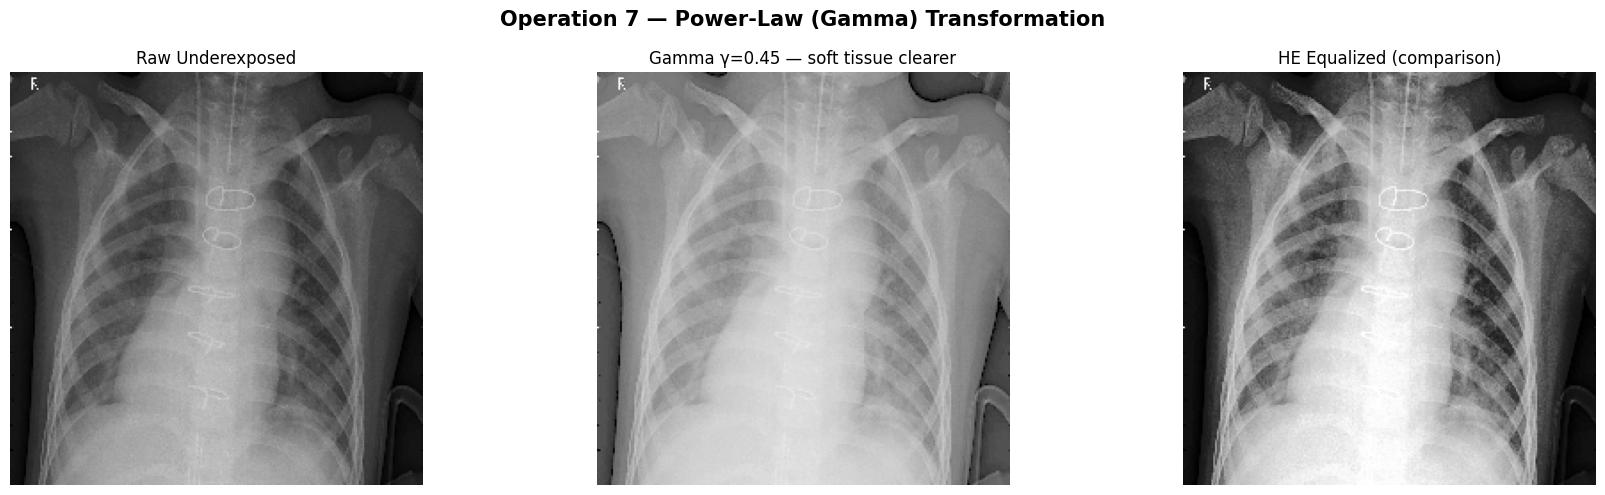

In [13]:
GAMMA = 0.45

normalized = underexposed.astype(np.float32) / 255.0
gamma_out  = np.clip(np.power(normalized, GAMMA) * 255.0, 0, 255).astype(np.uint8)

print(f'Gamma={GAMMA} — input mean={underexposed.mean():.1f}  output mean={gamma_out.mean():.1f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(underexposed, cmap='gray'); axes[0].set_title('Raw Underexposed');   axes[0].axis('off')
axes[1].imshow(gamma_out,    cmap='gray'); axes[1].set_title(f'Gamma γ={GAMMA} — soft tissue clearer'); axes[1].axis('off')
axes[2].imshow(equalized,    cmap='gray'); axes[2].set_title('HE Equalized (comparison)'); axes[2].axis('off')
plt.suptitle('Operation 7 — Power-Law (Gamma) Transformation', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

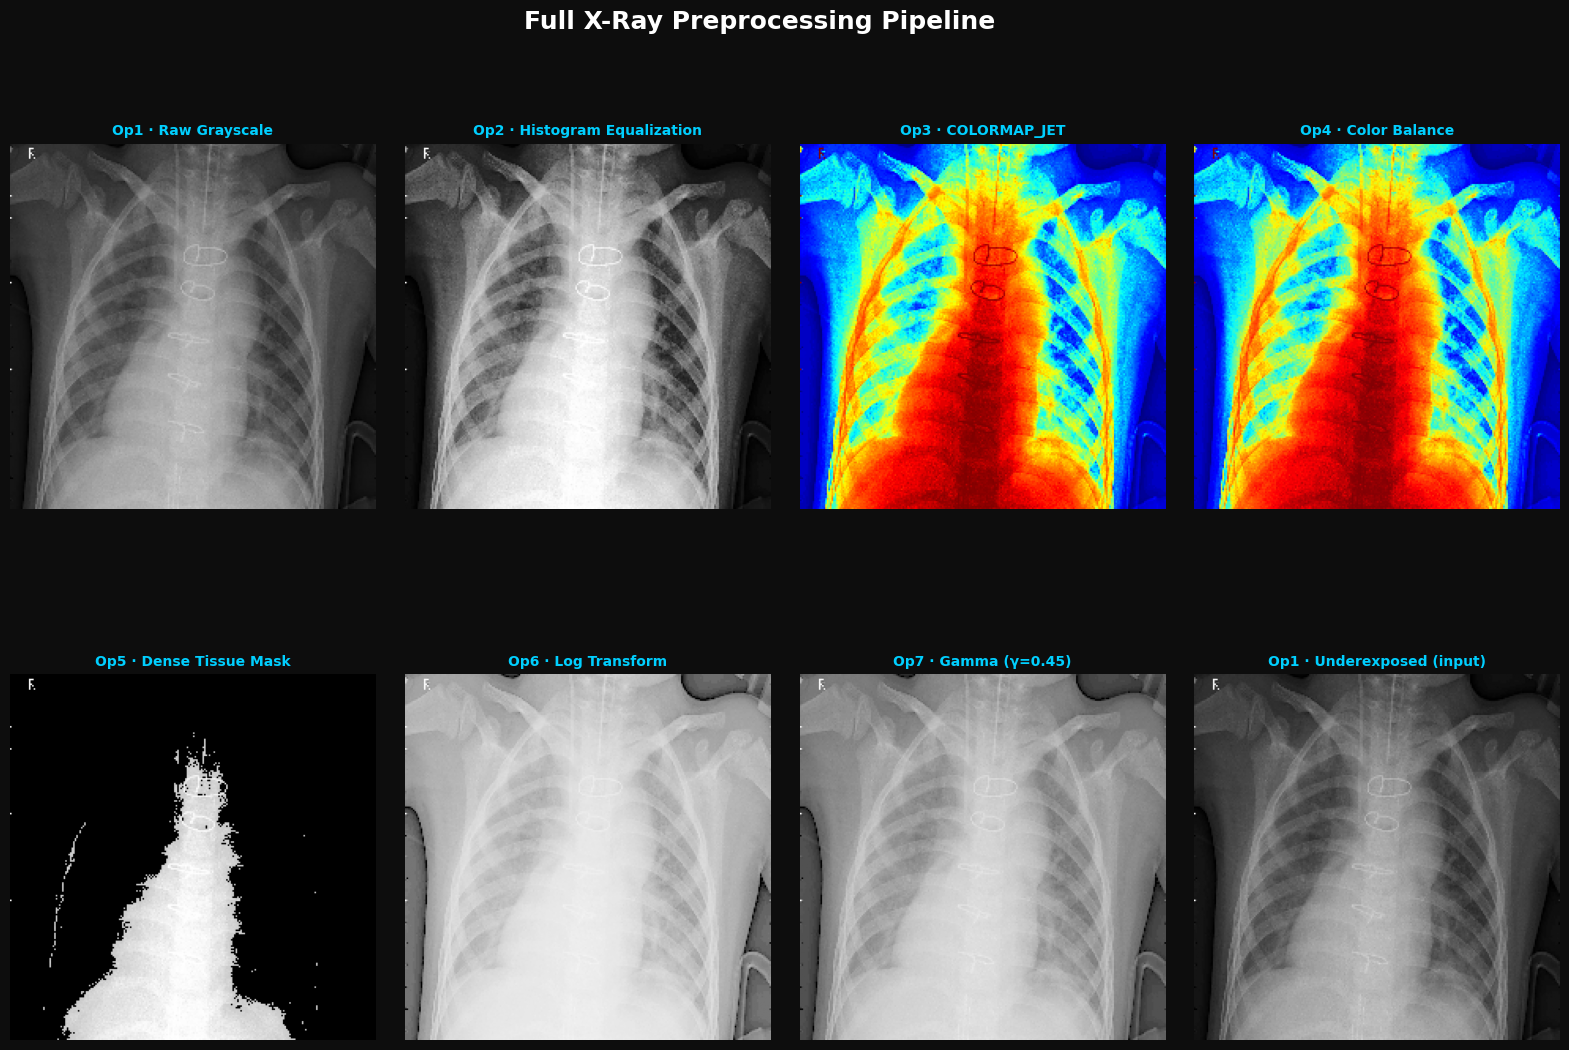

In [14]:
fig = plt.figure(figsize=(20, 12), facecolor='#0d0d0d')
fig.suptitle('Full X-Ray Preprocessing Pipeline', fontsize=18, fontweight='bold', color='white')
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.08)

panels = [
    ('Op1 · Raw Grayscale',           raw_gray,     'gray'),
    ('Op2 · Histogram Equalization',   equalized,    'gray'),
    ('Op3 · COLORMAP_JET',             jet_rgb,       None),
    ('Op4 · Color Balance',            balanced_rgb,  None),
    ('Op5 · Dense Tissue Mask',        dense_masked, 'gray'),
    ('Op6 · Log Transform',            log_out,      'gray'),
    (f'Op7 · Gamma (γ={GAMMA})',       gamma_out,    'gray'),
    ('Op1 · Underexposed (input)',     underexposed, 'gray'),
]

for i, (title, img, cmap) in enumerate(panels):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.imshow(img, cmap=cmap) if cmap else ax.imshow(img)
    ax.set_title(title, color='#00cfff', fontsize=10, fontweight='bold', pad=6)
    ax.axis('off')

plt.show()